In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings


# Pendahuluan

## Latar Belakang

Adopsi AI generatif di dunia pendidikan tinggi berkembang pesat. Namun, Konsultan pendidikan Indonesia belum memiliki data 
empiris yang kuat untuk menentukan kebijakan penggunaan AI yang tepat. Pertanyaan kunci yang dihadapi manajemen adalah: 
- Apakah penggunaan AI generatif meningkatkan atau menurunkan IPK mahasiswa? 
- Apakah mahasiswa yang sangat bergantung pada AI mengalami penurunan retensi pengetahuan? 
- Bagaimana kebijakan institusi (melarang/mengizinkan/mendorong) memengaruhi performa dan kesehatan mental? 
- Mahasiswa dengan profil seperti apa yang paling berisiko mengalami burnout?

## Stakeholders

* **Manajemen Perusahaan Konsultan:** Pengguna utama hasil analisis untuk basis layanan konsultasi kebijakan.
* **Pimpinan Perguruan Tinggi (Klien):** Pengambil kebijakan terkait status penggunaan AI di kampus (*Strict Ban*, *Allowed With Citation*, atau *Actively Encouraged*).
* **Dosen & Tenaga Pendidik:** Pihak yang menggunakan wawasan ini untuk menyesuaikan metode pengajaran dan standar evaluasi akademik.

## Pertanyaan Analitik Terukur

1. **Evaluasi Performa Akademik:** Bagaimana pengaruh intensitas jam penggunaan AI generatif (`Weekly_GenAI_Hours`) terhadap signifikansi perubahan IPK mahasiswa (selisih antara `Post_Semester_GPA` dan `Pre_Semester_GPA`)?
2. **Evaluasi Retensi Pengetahuan:** Apakah terdapat korelasi negatif yang terukur antara tingkat skor ketergantungan mahasiswa pada AI (`Perceived_AI_Dependency`) dengan skor retensi pengetahuan pasca-semester (`Skill_Retention_Score`)?
3. **Dampak Kebijakan:** Bagaimana perbedaan pencapaian peningkatan performa akademik (`Post_Semester_GPA`) serta tingkat kesehatan mental (`Anxiety_Level_During_Exams` dan `Burnout_Risk_Level`) jika dibandingkan antara ketiga kelompok kebijakan institusi (`Institutional_Policy`)?
4. **Profil Risiko Burnout:** Karakteristik demografi akademik apa (kombinasi `Major_Category`, `Year_of_Study`, dan `Traditional_Study_Hours`) yang mendominasi kelompok mahasiswa dengan risiko *burnout* tinggi (`Burnout_Risk_Level` = "High")?
5. **Efektivitas Penggunaan:** Dari berbagai tujuan penggunaan utama AI (`Primary_Use_Case`), tujuan manakah yang paling berkontribusi terhadap pencapaian IPK akhir (`Post_Semester_GPA`) tertinggi?

## Matriks Kebutuhan Data (Data Requirement Matrix)

*Catatan: Seluruh kebutuhan variabel dalam analisis ini diekstrak dari satu sumber data utama, yaitu file `ai_student_impact_dataset (1).csv`.*

| No. | Pertanyaan Analitik (Tujuan Bisnis) | Variabel yang Dibutuhkan |
| :--- | :--- | :--- |
| 1 | Dampak Akademik (Perubahan IPK) | `Weekly_GenAI_Hours`, `Pre_Semester_GPA`, `Post_Semester_GPA` |
| 2 | Retensi Pengetahuan | `Perceived_AI_Dependency`, `Skill_Retention_Score` |
| 3 | Dampak Kebijakan (Performa & Mental) | `Institutional_Policy`, `Post_Semester_GPA`, `Anxiety_Level_During_Exams`, `Burnout_Risk_Level` |
| 4 | Profil Risiko Burnout | `Major_Category`, `Year_of_Study`, `Traditional_Study_Hours`, `Burnout_Risk_Level` |
| 5 | Efektivitas Penggunaan | `Primary_Use_Case`, `Post_Semester_GPA` |

## Ruang Lingkup, Asumsi, dan Batasan Analisis

* **Ruang Lingkup:** Analisis mencakup data profil akademik, perilaku penggunaan AI, kebiasaan belajar, kebijakan institusi, dan indikator kesehatan mental mahasiswa selama satu semester penuh.
* **Asumsi:** Pengisian kuesioner mandiri (*self-reported*) oleh mahasiswa mengenai jam belajar dan durasi penggunaan AI dianggap jujur, valid, dan representatif terhadap kondisi riil.
* **Batasan:** Dataset bersifat *cross-sectional* (diambil dalam satu rentang waktu), sehingga hubungan antar variabel yang ditemukan merupakan **tren asosiasi** dan tidak serta-merta menunjukkan hubungan sebab-akibat (*causation*) yang mutlak. Analisis ini ditujukan untuk memberikan rekomendasi kebijakan bagi konteks ekosistem pendidikan tinggi di Indonesia.

## Pengumpulan dan Profiling Data

**Dokumentasi Pengumpulan Data:**
* **Metode Perolehan:** Data dikumpulkan melalui gabungan survei mahasiswa dan ekstraksi log dari Sistem Informasi Akademik universitas.
* **Periode Pengumpulan:** Data diambil selama satu semester penuh akademik.
* **Potensi Bias Sampling:** 1. **Self-Reporting Bias:** Risiko mahasiswa melaporkan estimasi jam (`Weekly_GenAI_Hours`, `Traditional_Study_Hours`) yang kurang akurat.
    2. **Selection Bias:** Mahasiswa yang mengisi survei kesehatan mental mungkin memiliki tingkat kerentanan stres yang berbeda dari total populasi.

In [2]:
# 1. Memuat dataset
df = pd.read_csv("data/ai_student_impact_dataset (1).csv")

In [3]:
# 2. Memeriksa dimensi data
print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")

Dimensi Dataset: 50000 baris, 16 kolom



In [4]:
# 3. Memeriksa tipe data dan nilai non-null
print("=== Struktur Data ===")
print(df.info())

=== Struktur Data ===
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  str    
 1   Major_Category              49998 non-null  str    
 2   Year_of_Study               49998 non-null  str    
 3   Pre_Semester_GPA            49998 non-null  float64
 4   Weekly_GenAI_Hours          49998 non-null  float64
 5   Primary_Use_Case            49998 non-null  str    
 6   Prompt_Engineering_Skill    49998 non-null  str    
 7   Tool_Diversity              49998 non-null  float64
 8   Paid_Subscription           49998 non-null  object 
 9   Traditional_Study_Hours     49998 non-null  float64
 10  Perceived_AI_Dependency     49998 non-null  float64
 11  Institutional_Policy        49998 non-null  str    
 12  Anxiety_Level_During_Exams  49998 non-null  float64
 13  Post_Semester_GPA   

In [5]:
# 4. Memeriksa jumlah missing values di setiap kolom
print("\n=== Jumlah Missing Values Per Kolom ===")
print(df.isnull().sum())


=== Jumlah Missing Values Per Kolom ===
Student_ID                    0
Major_Category                2
Year_of_Study                 2
Pre_Semester_GPA              2
Weekly_GenAI_Hours            2
Primary_Use_Case              2
Prompt_Engineering_Skill      2
Tool_Diversity                2
Paid_Subscription             2
Traditional_Study_Hours       2
Perceived_AI_Dependency       2
Institutional_Policy          2
Anxiety_Level_During_Exams    2
Post_Semester_GPA             2
Skill_Retention_Score         2
Burnout_Risk_Level            2
dtype: int64


In [6]:
# 5.  Menghitung duplikat
print("\n=== Jumlah Duplikat ===")
print(f"Total baris duplikat: {df.duplicated().sum()}")


=== Jumlah Duplikat ===
Total baris duplikat: 0


In [7]:
# 6. Distribusi tipe data
print("\n=== Distribusi Tipe Data ===")
print(df.dtypes.value_counts())


=== Distribusi Tipe Data ===
float64    8
str        7
object     1
Name: count, dtype: int64


**Kesimpulan Profiling Awal:**
Dataset dimuat dari file `ai_student_impact_dataset (1).csv` yang berisi 50.000 baris data mahasiswa dengan 16 variabel. Berdasarkan inspeksi awal, ditemukan bahwa tidak ada data duplikat. Struktur data terdiri dari tipe numerik `float64` (8 kolom) dan teks kategorikal `object` (8 kolom). Selain itu, hampir seluruh variabel memiliki tepat 2 baris data yang kosong (*missing values*) yang akan ditangani pada tahap pembersihan data.

## Kamus Data (Data Dictionary)

Berdasarkan dokumen panduan variabel dan hasil pemeriksaan struktur data, berikut adalah kamus data untuk 16 variabel yang tersedia:

| No | Nama Kolom | Tipe Data | Rentang Nilai / Kategori | Definisi Bisnis |
| :--- | :--- | :--- | :--- | :--- |
| 1 | `Student_ID` | Numerik | 100001 - 150000 | ID unik mahasiswa. |
| 2 | `Major_Category` | Kategorikal | STEM, Business, Humanities, Medical, Arts | Bidang studi mahasiswa. |
| 3 | `Year_of_Study` | Kategorikal | Freshman, Sophomore, Junior, Senior, Graduate | Jenjang perkuliahan mahasiswa. |
| 4 | `Pre_Semester_GPA` | Numerik | Skala 1.18 - 4.00 | IPK awal semester. |
| 5 | `Weekly_GenAI_Hours` | Numerik | 0 - 40 jam | Rata-rata jam/minggu menggunakan AI generatif. |
| 6 | `Primary_Use_Case` | Kategorikal | Copywriting/Drafting, Summarizing_Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation | Tujuan utama penggunaan AI. |
| 7 | `Prompt_Engineering_Skill`| Kategorikal | Beginner, Intermediate, Advanced | Kemampuan membuat prompt AI. |
| 8 | `Tool_Diversity` | Numerik | 1 - 5 | Jumlah tool AI berbeda yang digunakan. |
| 9 | `Paid_Subscription` | Boolean | True / False | Status apakah berlangganan AI berbayar. |
| 10 | `Traditional_Study_Hours` | Numerik | 1 - 36 jam | Jam belajar tradisional (non-AI) per minggu. |
| 11 | `Perceived_AI_Dependency` | Numerik | Skala 1 - 10 | Skor ketergantungan pada AI (1=rendah, 10=tinggi). |
| 12 | `Institutional_Policy` | Kategorikal | Allowed_With_Citation, Strict_Ban, Actively_Encouraged | Kebijakan institusi kampus terkait penggunaan AI. |
| 13 | `Anxiety_Level_During_Exams`| Numerik | Skala 1 - 10 | Skor kecemasan ujian (1=minimal, 10=sangat tinggi). |
| 14 | `Post_Semester_GPA` | Numerik | Skala 1.00 - 4.00 | IPK akhir semester (variabel output utama). |
| 15 | `Skill_Retention_Score` | Numerik | Skor 0 - 100 | Skor retensi pengetahuan pasca-semester. |
| 16 | `Burnout_Risk_Level` | Kategorikal | Low, Medium, High | Tingkat risiko burnout mahasiswa. |

# EDA (Exploratory Data Analysis)

Tahap ini bertujuan untuk memahami distribusi data, mendeteksi anomali awal, dan menemukan insight menarik melalui statistik deskriptif dan visualisasi (Modul 3).

## Statistik Deskriptif

In [8]:
# Statistik Deskriptif Variabel Numerik
print("=== STATISTIK DESKRIPTIF (NUMERIK) ===")
# include=[np.number] untuk memastikan hanya kolom angka yang dihitung
display(df.describe(include=['float64', 'int64']).T)

=== STATISTIK DESKRIPTIF (NUMERIK) ===


,count,mean,std,min,25%,50%,75%,max
Pre_Semester_GPA,49998.0,3.146289,0.480575,1.183,2.834,3.210,3.5210,12.249
Weekly_GenAI_Hours,49998.0,8.427897,8.269604,0.000,2.390,5.800,11.7200,40.000
Tool_Diversity,49998.0,2.800532,1.189907,1.000,2.000,3.000,4.0000,18.000
Traditional_Study_Hours,49998.0,11.209241,5.156449,1.000,7.560,11.180,14.7100,35.860
Perceived_AI_Dependency,49998.0,3.505360,1.820846,1.000,2.000,3.000,5.0000,10.000
Anxiety_Level_During_Exams,49998.0,4.270891,2.144010,1.000,3.000,4.000,6.0000,10.000
Post_Semester_GPA,49998.0,3.349447,0.496665,1.000,3.024,3.421,3.7490,10.389
Skill_Retention_Score,49998.0,75.797982,13.281748,10.780,66.820,76.000,85.1875,100.000


**📌 Insight Perilaku Mahasiswa:**

* **Belajar Tradisional vs AI:** Secara rata-rata, mahasiswa masih lebih banyak menghabiskan waktu untuk belajar secara tradisional (11,2 jam/minggu) dibandingkan menggunakan AI (8,4 jam/minggu).
* **Distribusi Penggunaan AI:** Kolom `Weekly_GenAI_Hours` condong ke kanan (*right-skewed*). Hal ini terlihat dari nilai rata-rata (8,4 jam) yang lebih tinggi dari nilai tengah/median (5,8 jam). Artinya, mayoritas mahasiswa menggunakan AI secukupnya, namun ada segelintir *outlier* yang menggunakannya secara ekstrem (hingga maksimum 40 jam/minggu).
* **Kecemasan Ujian Cukup Terkendali:** Rata-rata tingkat kecemasan ujian berada di angka 4,27 (dari skala 10), dengan 75% populasi (Q3) berada di angka 6 ke bawah.

**⚠️ Indikasi Anomali (Target Pembersihan di Modul 4):**

* **Kejanggalan Skala IPK:** Nilai maksimum pada `Pre_Semester_GPA` (12,24) dan `Post_Semester_GPA` (10,38) jelas merupakan data yang tidak logis karena jauh melebihi batas maksimal IPK yang wajar (4,00).
* **Kejanggalan Tool Diversity:** Nilai maksimum `Tool_Diversity` tercatat mencapai 18, padahal berdasarkan kamus data rentang yang diizinkan hanya 1-5.
* **Konfirmasi Missing Values:** Semua kolom numerik memiliki `count` sebanyak 49.998. Ini membuktikan secara matematis bahwa terdapat tepat 2 baris *missing values* dari total 50.000 baris data awal.

## Distribusi Variabel Kategorik

In [9]:
# Distribusi Frekuensi & Persentase Variabel Kategorikal Utama
print("\n=== DISTRIBUSI VARIABEL KATEGORIKAL ===")
kategorikal_utama = ['Major_Category', 'Year_of_Study', 'Burnout_Risk_Level', 
                     'Institutional_Policy', 'Primary_Use_Case']

for col in kategorikal_utama:
    print(f"\n--- {col} ---")
    # Menghitung frekuensi (jumlah)
    freq = df[col].value_counts()
    # Menghitung persentase
    perc = df[col].value_counts(normalize=True) * 100
    
    # Menggabungkan ke dalam satu DataFrame agar rapi
    dist_df = pd.DataFrame({'Frekuensi': freq, 'Persentase (%)': perc.round(2)})
    display(dist_df)


=== DISTRIBUSI VARIABEL KATEGORIKAL ===

--- Major_Category ---


,Frekuensi,Persentase (%)
Major_Category,,
STEM,15059,30.12
Business,12537,25.08
Humanities,9994,19.99
Medical,6475,12.95
Arts,5933,11.87



--- Year_of_Study ---


,Frekuensi,Persentase (%)
Year_of_Study,,
Junior,11043,22.09
Freshman,11030,22.06
Senior,10634,21.27
Sophomore,9860,19.72
Graduate,7430,14.86
123,1,0.00



--- Burnout_Risk_Level ---


,Frekuensi,Persentase (%)
Burnout_Risk_Level,,
Medium,21143,42.29
Low,16369,32.74
High,12486,24.97



--- Institutional_Policy ---


,Frekuensi,Persentase (%)
Institutional_Policy,,
Allowed_With_Citation,25223,50.45
Actively_Encouraged,14987,29.98
Strict_Ban,9788,19.58



--- Primary_Use_Case ---


,Frekuensi,Persentase (%)
Primary_Use_Case,,
Debugging/Troubleshooting,12295,24.59
Copywriting/Drafting,12011,24.02
Ideation,10720,21.44
Summarizing_Reading,8633,17.27
Direct_Answer_Generation,6339,12.68


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\1616744060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette="viridis")
C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\1616744060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette="viridis")
C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\1616744060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i],

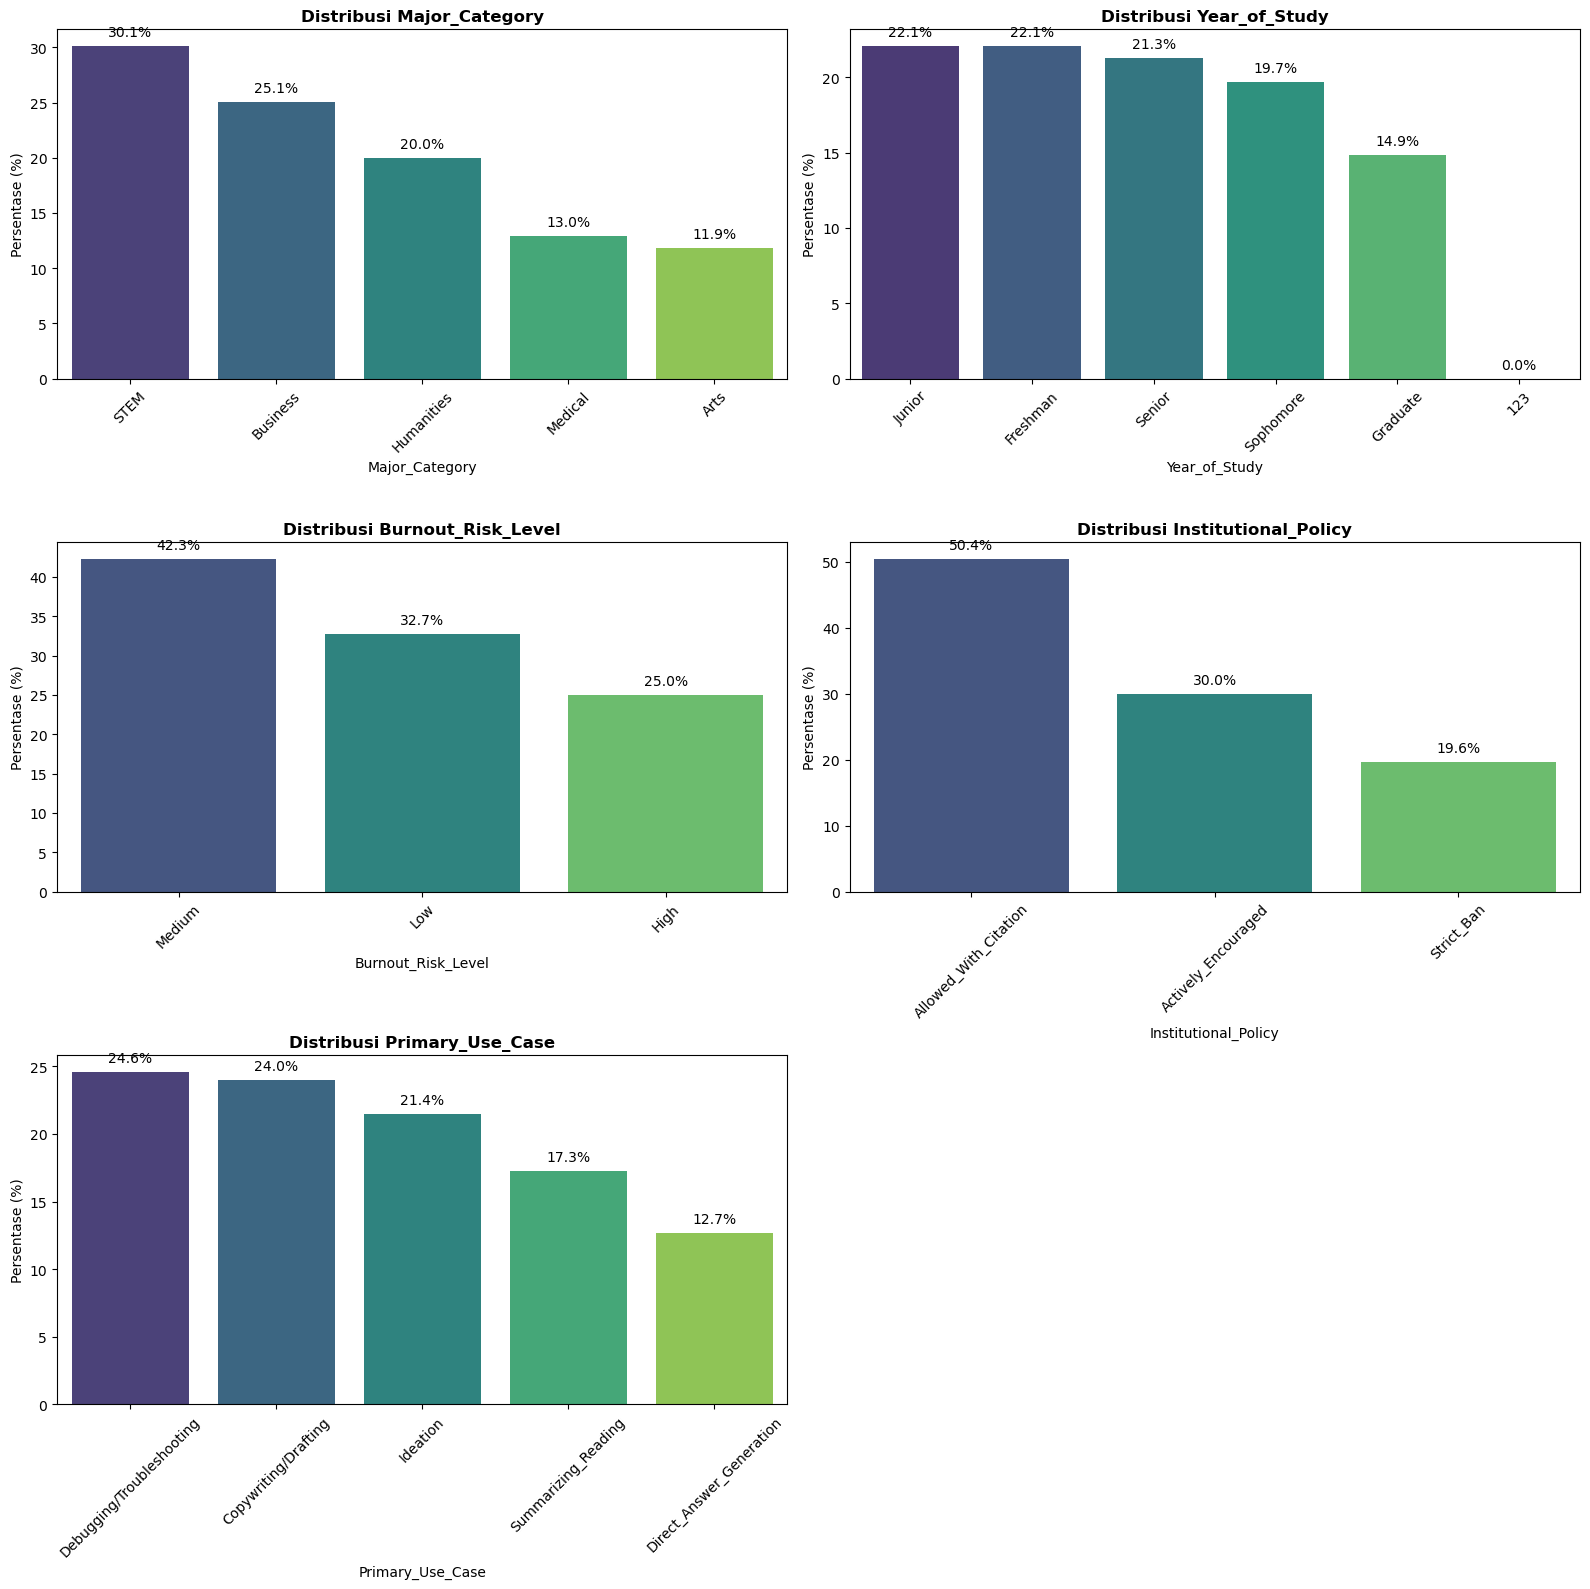

In [10]:
# Daftar variabel kategorikal yang ingin divisualisasikan
kategorikal_utama = ['Major_Category', 'Year_of_Study', 'Burnout_Risk_Level', 
                     'Institutional_Policy', 'Primary_Use_Case']

# Membuat subplots (grid 3 baris, 2 kolom)
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
# Meratakan array axes agar lebih mudah diakses dalam loop
axes = axes.flatten()

for i, col in enumerate(kategorikal_utama):
    # Menghitung persentase
    val_counts = df[col].value_counts(normalize=True) * 100
    
    # Membuat barplot
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette="viridis")
    
    # Menambahkan judul dan label
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)')
    
    # Memiringkan label x-axis agar tidak bertumpuk (khususnya untuk Primary_Use_Case)
    axes[i].tick_params(axis='x', rotation=45)

    # Menambahkan label angka persentase di atas setiap batang
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', 
                         xytext=(0, 5), textcoords='offset points', fontsize=10)

# Menghapus subplot ke-6 yang kosong (karena kita hanya punya 5 variabel)
fig.delaxes(axes[5])

# Menyesuaikan jarak antar subplot
plt.tight_layout()
plt.show()

📌 **Insight Distribusi Kategorikal:**

- Dominasi Mahasiswa STEM & Bisnis: Kategori jurusan ternyata tidak merata. Mahasiswa STEM (30.1%) dan Business (25.1%) mendominasi lebih dari setengah populasi responden, baru kemudian disusul oleh Humanities, Medical, dan Arts.

- Kecenderungan Burnout Menengah: Risiko burnout yang paling mendominasi justru ada di tingkat Medium (42.3%). Tingkat risiko High justru merupakan kelompok yang paling kecil (25.0%).

- Kebijakan Kampus Cenderung Moderat: Mayoritas institusi (lebih dari setengahnya) ternyata mengambil jalan tengah, yaitu mengizinkan penggunaan AI dengan syarat, Allowed_With_Citation (50.4%). Pelarangan penuh (Strict_Ban) adalah kebijakan yang paling sedikit diterapkan (19.6%).

- Penggunaan untuk Kebutuhan Teknis & Menulis: Debugging/Troubleshooting (24.6%) ternyata memimpin tipis sebagai tujuan utama penggunaan AI, disusul ketat oleh Copywriting/Drafting (24.0%). Penggunaan AI untuk sekadar mencari jawaban instan (Direct_Answer_Generation) justru paling jarang dilakukan (12.7%).

⚠️ **Indikasi Anomali (Catatan untuk Modul 4):**

- Kategori Nyasar di Year_of_Study: Kalau diperhatikan di ujung kanan grafik Year_of_Study, terdapat kategori aneh bernama "123" (meskipun persentasenya 0.0%). Ini jelas merupakan dirty data atau salah ketik (typo) yang harus dihapus atau perbaiki di tahap pembersihan data nanti.

## Visualisasi Pertanyaan Bisnis

Bagian ini berisi 6 visualisasi utama yang dirancang khusus untuk mengidentifikasi pola awal guna menjawab 5 pertanyaan analitik bisnis. Perlu dicatat bahwa data ini masih berupa data mentah (*raw data*) yang belum dibersihkan, sehingga anomali (seperti IPK > 4.0) mungkin masih terlihat pada visualisasi ini.

### Distribusi GPA (Pre vs Post) per kategori bidang studi

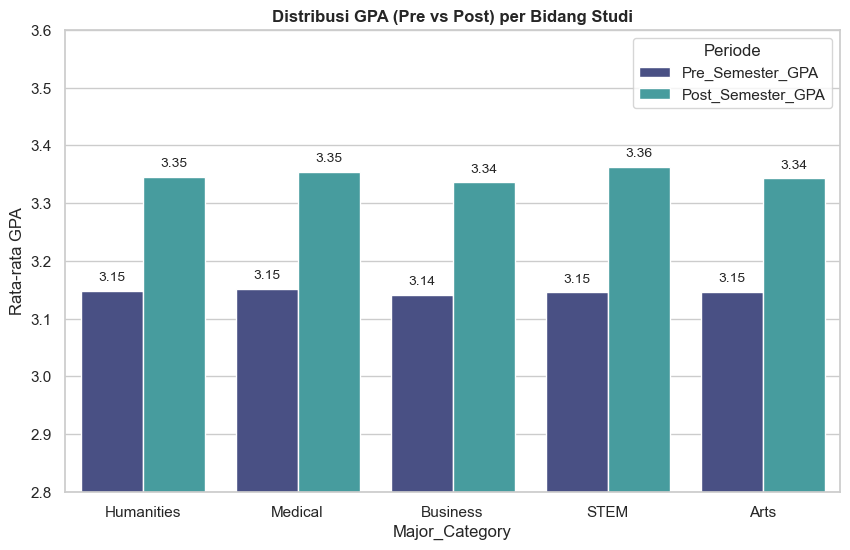

In [11]:
# --- 1. Distribusi GPA (Pre vs Post) per Bidang Studi ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Melt data
df_gpa = df[['Major_Category', 'Pre_Semester_GPA', 'Post_Semester_GPA']].melt(
    id_vars='Major_Category', var_name='Periode', value_name='GPA'
)

# Buat barplot
ax = sns.barplot(data=df_gpa, x='Major_Category', y='GPA', hue='Periode', palette='mako', errorbar=None)

# Trik: Membatasi sumbu Y (zoom in) agar selisihnya terlihat jelas
plt.ylim(2.8, 3.6)

plt.title('Distribusi GPA (Pre vs Post) per Bidang Studi', fontweight='bold')
plt.ylabel('Rata-rata GPA')

# Menambahkan label angka persis di atas setiap batang
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'bottom', 
                xytext = (0, 5), 
                textcoords = 'offset points',
                fontsize=10)

plt.show()

**Observasi:** 
- Terjadi lonjakan rata-rata IPK (sekitar 0.20 poin) yang sangat seragam dan konsisten di seluruh bidang studi, berangkat dari basis Pre-GPA yang sama (~3.15) menuju Post-GPA yang setara (~3.35).

**Insight:** 
- Peningkatan performa akademik ini bersifat universal di semua disiplin ilmu. Namun, dari metrik makro ini saja, tidak ada bukti empiris yang mengonfirmasi bahwa AI adalah penyebabnya. Ini sekadar menunjukkan tren positif akademik secara umum antar semester.

**Rekomendasi:**
- Untuk menghindari pengambilan keputusan yang bias, pihak manajemen tidak boleh langsung menyimpulkan efektivitas AI dari grafik ini. Disarankan untuk membedah data lebih dalam, misalnya dengan melakukan uji beda lanjutan (post-hoc) untuk membandingkan Delta GPA ini antara kelompok Heavy User AI dan kelompok yang jarang menggunakan AI, guna mengisolasi dampak murninya.

### Korelasi antara Weekly_GenAI_Hours dengan Post_Semester_GPA dan Skill_Retention_Score

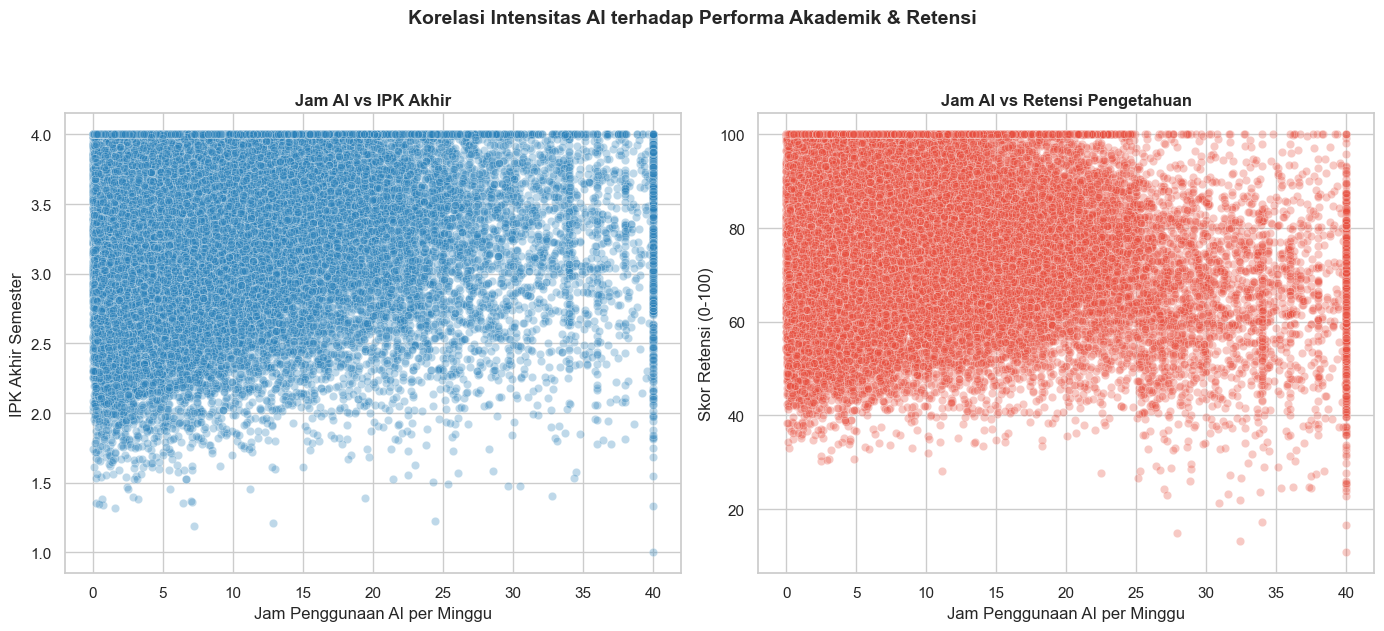

In [12]:
# --- 2. Korelasi Jam AI vs IPK Akhir & Retensi Skill (DIREVISI) ---
# Filter sementara HANYA UNTUK GRAFIK ini (membuang IPK > 4.0)
df_clean_plot = df[df['Post_Semester_GPA'] <= 4.0]

# Membuat figure dengan 1 baris, 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sub-grafik 1: Jam AI vs IPK Akhir
sns.scatterplot(data=df_clean_plot, x='Weekly_GenAI_Hours', y='Post_Semester_GPA', 
                alpha=0.3, color='#2980b9', ax=axes[0])
axes[0].set_title('Jam AI vs IPK Akhir', fontweight='bold')
axes[0].set_xlabel('Jam Penggunaan AI per Minggu')
axes[0].set_ylabel('IPK Akhir Semester')

# Sub-grafik 2: Jam AI vs Retensi Skill
sns.scatterplot(data=df_clean_plot, x='Weekly_GenAI_Hours', y='Skill_Retention_Score', 
                alpha=0.3, color='#e74c3c', ax=axes[1])
axes[1].set_title('Jam AI vs Retensi Pengetahuan', fontweight='bold')
axes[1].set_xlabel('Jam Penggunaan AI per Minggu')
axes[1].set_ylabel('Skor Retensi (0-100)')

plt.suptitle('Korelasi Intensitas AI terhadap Performa Akademik & Retensi', fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

**Observasi:** 
- Pada kedua grafik, sebaran data terlihat stabil hingga penggunaan AI mencapai kisaran 25 jam/minggu. Namun, setelah melewati batas 25 jam, muncul titik-titik yang "jatuh" ke bawah, menunjukkan anjloknya IPK Akhir (mendekati 1.0) dan Skor Retensi Pengetahuan (merosot hingga di bawah 40).

**Insight:** 
- Ini adalah bukti nyata terjadinya diminishing returns (hasil yang makin menurun) akibat over-reliance. Mahasiswa yang menggunakan AI secara ekstrem bukan lagi menjadikannya sebagai asisten belajar, melainkan membiarkan AI berpikir sepenuhnya menggantikan mereka. Akibatnya, pemahaman materi (retensi) hancur dan nilai ujian jatuh.

**Rekomendasi:**
- Kampus perlu menerapkan sistem evaluasi yang lebih ketat untuk mengimbangi kemudahan AI. Perbesar porsi dan bobot ujian lisan, diskusi kelas, atau ujian tertulis tanpa perangkat (closed-book/no-device) untuk memastikan kemampuan kognitif asli mahasiswa tetap teruji.

### Distribusi Burnout_Risk_Level per kebijakan institusi

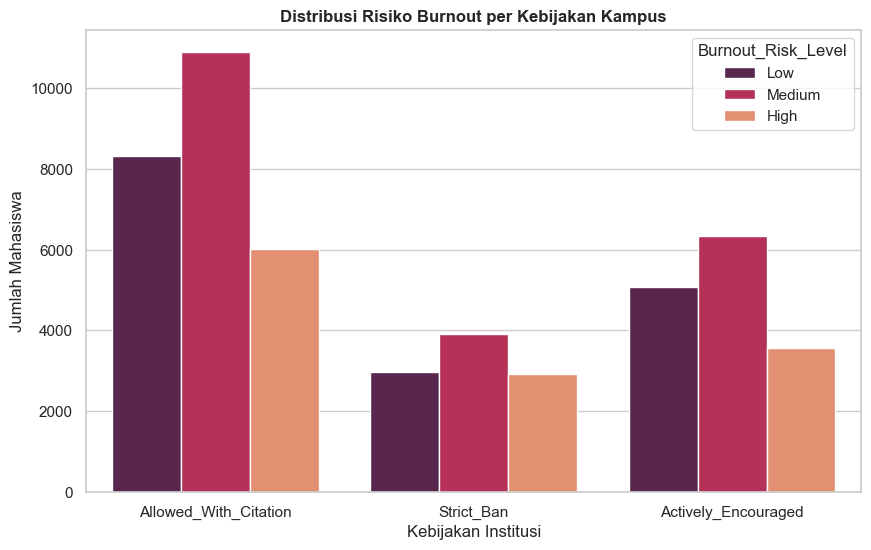

In [13]:
# --- 3. Distribusi Risiko Burnout per Kebijakan Kampus ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Institutional_Policy', hue='Burnout_Risk_Level', 
              palette='rocket', hue_order=['Low', 'Medium', 'High'])
plt.title('Distribusi Risiko Burnout per Kebijakan Kampus', fontweight='bold')
plt.xlabel('Kebijakan Institusi')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

**Observasi:** 
- Jika membandingkan proporsinya, kebijakan Strict_Ban memiliki rasio High Burnout yang sangat mencolok, di mana jumlah mahasiswa berisiko tinggi hampir menyamai yang berisiko rendah (mendekati 1:1). Sebaliknya, pada lingkungan Allowed_With_Citation dan Actively_Encouraged, jumlah mahasiswa berisiko rendah masih jauh melampaui yang berisiko tinggi.

**Insight:** 
- Larangan total (Strict Ban) terhadap AI tidak serta-merta menciptakan lingkungan akademik yang sehat, melainkan justru memicu tekanan mental yang lebih besar. Tanpa akses ke AI sebagai alat efisiensi, beban tugas manual mahasiswa tetap berat, sehingga risiko kelelahan ekstrem (burnout) melonjak lebih tinggi.

**Rekomendasi:**
- Kampus sangat tidak disarankan menerapkan larangan buta terhadap AI. Pendekatan Allowed_With_Citation adalah jalan tengah terbaik untuk diadopsi, karena berhasil menekan proporsi burnout sekaligus tetap menjaga standar integritas akademik lewat aturan sitasi yang jelas.

### Heatmap korelasi antar variabel numerik

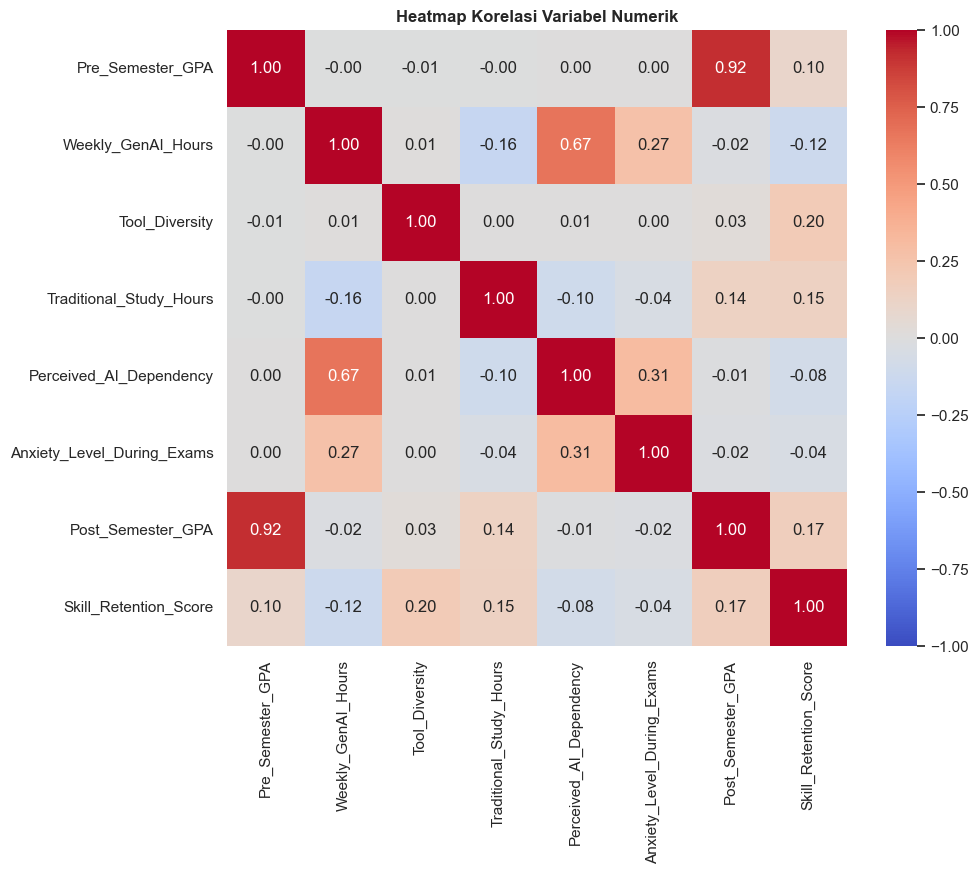

In [14]:
# --- 4. Heatmap Korelasi Variabel Numerik ---

plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Numerik', fontweight='bold')
plt.show()

**Observasi:** 
- Korelasi terkuat (selain historis IPK) terjadi antara Jam Penggunaan AI dengan Ketergantungan AI (0.67) dan Kecemasan Ujian (0.27). Di sisi lain, Jam Penggunaan AI justru berkorelasi negatif dengan Jam Belajar Tradisional (-0.16) dan Retensi Pengetahuan (-0.12), serta sama sekali tidak berkorelasi dengan IPK Akhir (-0.02).

**Insight:** 
- Penggunaan AI dengan intensitas tinggi tidak memberikan jaminan IPK naik. Sebaliknya, hal itu justru membuat mahasiswa mengurangi jam belajar mandiri, menurunkan daya ingat materi, dan membuat mereka jauh lebih cemas saat menghadapi ujian (kemungkinan karena mereka terbiasa dibantu AI dan panik saat ujian berlangsung tanpa alat bantu).

**Rekomendasi:**
- Institusi perlu mengampanyekan literasi "AI yang Sehat". Kampus sebaiknya memperbanyak format ujian tertutup (closed-book/no-device) agar mahasiswa menyadari bahwa mereka tetap harus membangun fondasi pengetahuan dan jam belajar konvensional untuk bisa bertahan, bukan sekadar bergantung pada AI.

### Tren penggunaan AI per jenjang studi (Year_of_Study) 

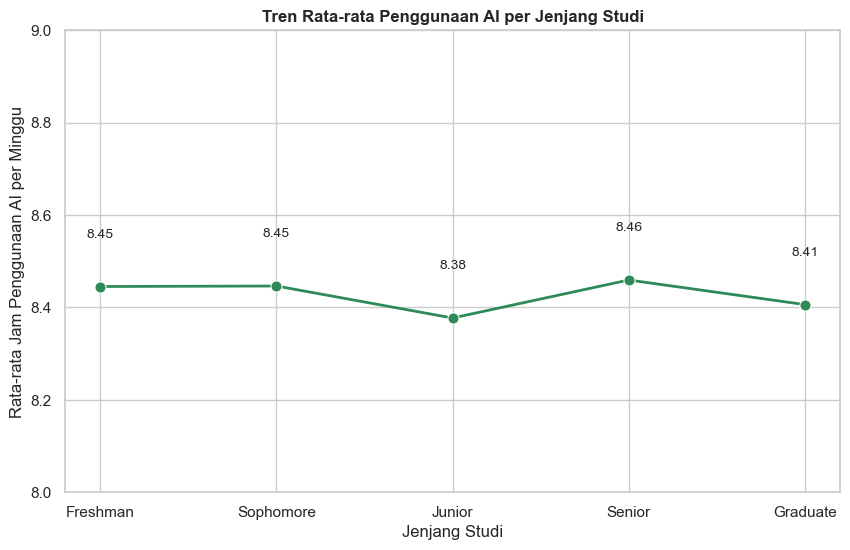

In [15]:
# --- 5. Tren Rata-rata Penggunaan AI per Jenjang Studi  ---
plt.figure(figsize=(10, 6))

# Tentukan urutan yang benar secara logis
urutan_studi = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']

# Filter data untuk membuang anomali "123" HANYA UNTUK PLOT INI
df_tren = df[df['Year_of_Study'].isin(urutan_studi)]

# Buat line plot, 'order' tidak berlaku untuk lineplot, jadi kita pastikan 'Year_of_Study' sudah dalam tipe kategori dengan urutan yang benar
df_tren['Year_of_Study'] = pd.Categorical(df_tren['Year_of_Study'], categories=urutan_studi, ordered=True)

# Agar garisnya terlihat mulus sesuai urutan, kita buat barplot saja dulu, atau lineplot dengan data yang di-groupby
# Cara paling aman dan rapi untuk tren agregat adalah groupby:
tren_agregat = df_tren.groupby('Year_of_Study')['Weekly_GenAI_Hours'].mean().reset_index()

sns.lineplot(data=tren_agregat, x='Year_of_Study', y='Weekly_GenAI_Hours', 
             marker='o', color='seagreen', linewidth=2, markersize=8)

plt.title('Tren Rata-rata Penggunaan AI per Jenjang Studi', fontweight='bold')
plt.xlabel('Jenjang Studi')
plt.ylabel('Rata-rata Jam Penggunaan AI per Minggu')

# Tambahkan label angka di setiap titik agar lebih informatif
for x, y in zip(range(len(tren_agregat)), tren_agregat['Weekly_GenAI_Hours']):
    plt.text(x, y + 0.1, f'{y:.2f}', ha='center', va='bottom', fontsize=10)

plt.ylim(8.0, 9.0) # Zoom in ke skala yang relevan
plt.show()

**Observasi:** 
- Tren rata-rata waktu penggunaan AI cenderung sangat datar di semua tingkat. Dari Freshman hingga Graduate, rata-rata penggunaannya konsisten berada di kisaran sempit 8.38 hingga 8.46 jam per minggu (selisih kurang dari 5 menit).

**Insight:** 
- Adopsi AI bersifat universal. Tidak ada "kurva adaptasi" atau perbedaan intensitas kebutuhan antara mahasiswa baru dan mahasiswa tingkat akhir. AI telah menjadi alat bantu standar yang melekat di seluruh fase kehidupan akademik tanpa memandang senioritas.

**Rekomendasi:**
- Institusi tidak perlu merancang kebijakan AI yang bertingkat (misal: dilarang untuk mahasiswa baru, tapi diizinkan untuk mahasiswa tingkat akhir). Kebijakan harus diterapkan seragam secara universal, dengan titik fokus pada cara penggunaannya, bukan jam pemakaiannya.

### Boxplot Perceived_AI_Dependency vs Burnout_Risk_Level

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\1038689298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Burnout_Risk_Level', y='Perceived_AI_Dependency',


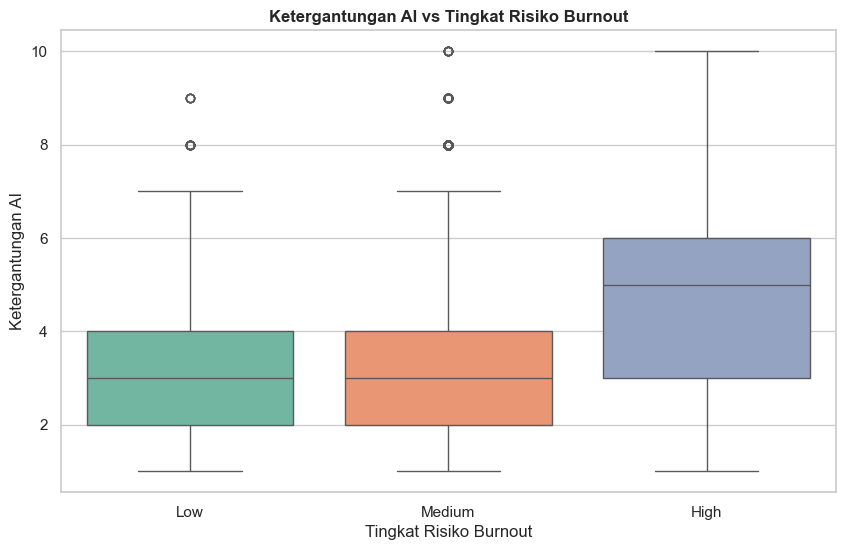

In [16]:
# --- 6. Ketergantungan AI vs Tingkat Risiko Burnout ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Burnout_Risk_Level', y='Perceived_AI_Dependency', 
            palette='Set2', order=['Low', 'Medium', 'High'])
plt.title('Ketergantungan AI vs Tingkat Risiko Burnout', fontweight='bold')
plt.xlabel('Tingkat Risiko Burnout')
plt.ylabel('Ketergantungan AI')
plt.show()

**Observasi:** 
- Kelompok mahasiswa dengan tingkat High Burnout memiliki nilai tengah (median) ketergantungan AI paling tinggi (skor 5) dan sebarannya mencapai skor maksimal (10), berbeda jauh dengan kelompok Low dan Medium yang berpusat di skor 3.

**Insight:** 
- Ada korelasi kuat antara kelelahan mental dengan ketergantungan AI. Mahasiswa yang kelelahan (burnout) cenderung menjadikan AI sebagai "jalan pintas" atau pelarian karena kapasitas mental mereka untuk mengerjakan tugas sudah habis.

**Rekomendasi:**
- Kampus (terutama bagian Bimbingan Akademik/Konseling) dapat menjadikan "lonjakan drastis penggunaan AI" sebagai red flag (peringatan dini) untuk mendeteksi dan memberikan pendampingan kepada mahasiswa yang rentan burnout.

### Efektivitas Penggunaan AI

Tabel Rata-rata IPK berdasarkan Tujuan Penggunaan AI:


,Primary_Use_Case,mean,count
1,Debugging/Troubleshooting,3.395840,12295
4,Summarizing_Reading,3.350746,8633
3,Ideation,3.343658,10720
0,Copywriting/Drafting,3.335306,12011
2,Direct_Answer_Generation,3.294278,6339


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\3615144080.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


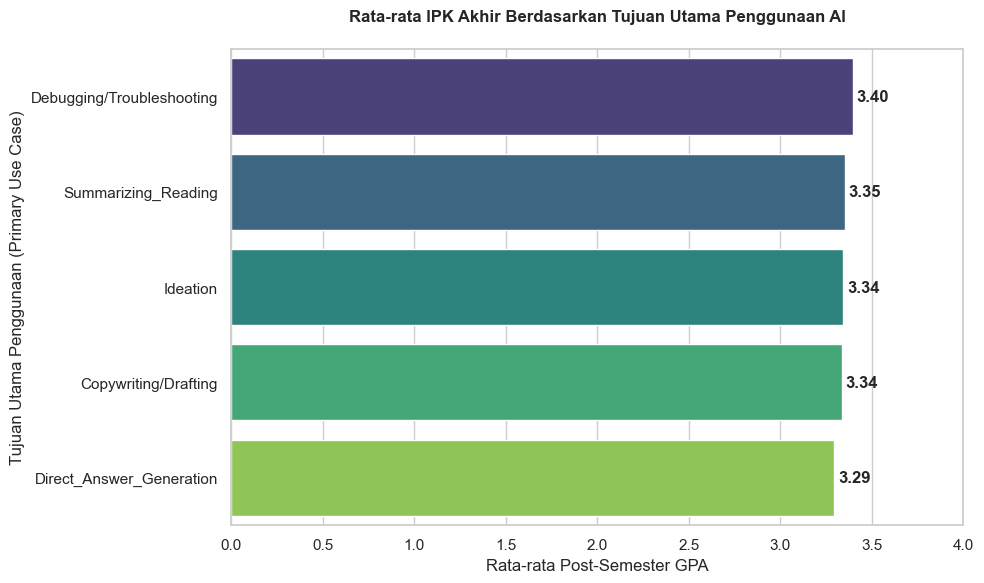

In [17]:
# 1. Melakukan agregasi data
df_use_case = df.groupby('Primary_Use_Case')['Post_Semester_GPA'].agg(['mean', 'count']).reset_index()

# 2. Mengurutkan dari rata-rata IPK tertinggi ke terendah
df_use_case = df_use_case.sort_values(by='mean', ascending=False)

# 3. Menampilkan tabel hasil agregasi
print("Tabel Rata-rata IPK berdasarkan Tujuan Penggunaan AI:")
display(df_use_case)

# 4. Membuat visualisasi (Horizontal Bar Chart) untuk EDA
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_use_case, 
    x='mean', 
    y='Primary_Use_Case', 
    palette='viridis'
)

# Menambahkan label nilai di ujung bar
for index, value in enumerate(df_use_case['mean']):
    plt.text(value + 0.02, index, f'{value:.2f}', va='center', fontweight='bold')

plt.title('Rata-rata IPK Akhir Berdasarkan Tujuan Utama Penggunaan AI', pad=20, fontweight='bold')
plt.xlabel('Rata-rata Post-Semester GPA')
plt.ylabel('Tujuan Utama Penggunaan (Primary Use Case)')
plt.xlim(0, 4.0) # Mengunci sumbu X dari 0 sampai skala IPK maksimal (4.0)
plt.tight_layout()
plt.show()

**Observasi:** 
- Kelompok mahasiswa yang menggunakan AI untuk "Debugging/Troubleshooting" meraih rata-rata IPK tertinggi (3.40). Sebaliknya, penggunaan AI untuk "Direct_Answer_Generation" (mendapatkan jawaban instan) menempati posisi terendah dengan rata-rata IPK 3.29.

**Insight:** 
- Data ini membuktikan bahwa cara mahasiswa menggunakan AI sangat menentukan hasil akhirnya. AI terbukti paling efektif ketika difungsikan sebagai alat bantu problem-solving atau teman diskusi interaktif. Sebaliknya, menggunakan AI sebagai "jalan pintas" pasif untuk sekadar menyalin jawaban (Direct Answer) justru berkorelasi dengan performa akademik yang lebih rendah, mengindikasikan melemahnya proses berpikir analitis mahasiswa.

**Rekomendasi:**
- Institusi pendidikan sebaiknya merancang evaluasi atau tugas kuliah yang berfokus pada proses analisis dan penalaran mendalam, sehingga mahasiswa "terpaksa" menggunakan AI untuk mencari ide atau debugging, bukan sekadar menyalin hasil instan.

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_16300\1768818721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


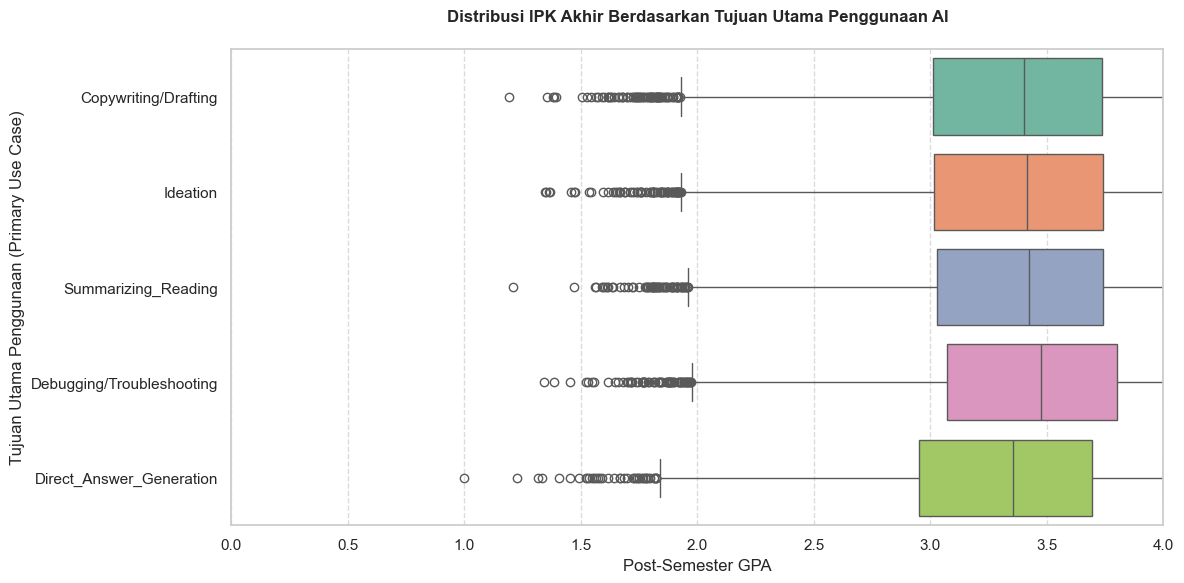

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Post_Semester_GPA',
    y='Primary_Use_Case',
    palette='Set2'
)
plt.title('Distribusi IPK Akhir Berdasarkan Tujuan Utama Penggunaan AI', pad=20, fontweight='bold')
plt.xlabel('Post-Semester GPA')
plt.ylabel('Tujuan Utama Penggunaan (Primary Use Case)')
plt.xlim(0, 4.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observasi:**
- Dari distribusi boxplot, kita bisa melihat bahwa nilai tengah (median) untuk kelompok Debugging/Troubleshooting berada di posisi tertinggi dibandingkan kategori lain. Sebaliknya, kelompok Direct_Answer_Generation memiliki median terendah dan memiliki rentang pencilan (outliers) bawah yang paling ekstrem, bahkan menyentuh angka IPK 1.0.

**Insight:** 
- Visualisasi ini mengonfirmasi temuan awal kita, sekaligus menambahkan konteks risiko. Mahasiswa yang menggunakan AI untuk mencari jawaban instan (Direct Answer) tidak hanya memiliki rata-rata performa yang lebih rendah, tetapi juga memiliki risiko kegagalan akademik yang parah (terlihat dari ekor outlier yang sangat panjang ke kiri). Sebaliknya, penggunaan AI untuk Debugging atau Ideation menggeser mayoritas (kotak IQR) performa mahasiswa mendekati batas maksimal IPK (4.0). Ini membuktikan bahwa AI bertindak sebagai katalisator bagi mahasiswa yang sudah memiliki daya analisis, namun menjadi bumerang bagi mereka yang pasif.

**Rekomendasi:**
- Sebagai tindak lanjut, pihak kampus disarankan untuk mengubah metode asesmen. Tugas yang jawabannya bisa diselesaikan murni dengan Direct Answer dari AI harus mulai dikurangi porsinya. Sebaliknya, dosen disarankan untuk memperbanyak tugas berbasis proyek (Project-Based Learning) atau studi kasus di mana AI hanya bisa difungsikan sebagai alat bantu Debugging atau pencarian ide pendukung (Ideation).

## Identifikasi Pola, Anomali, dan Insight Awal untuk Kebijakan

**1. Pola Utama yang Teridentifikasi (Key Patterns)**

- Adopsi AI yang Universal: Penggunaan AI generatif terdistribusi secara merata di seluruh jenjang studi (dari Freshman hingga Graduate) dengan durasi rata-rata yang stabil di kisaran 8.4 jam/minggu. Meskipun terlihat adanya tren peningkatan nilai dari Pre-Semester GPA ke Post-Semester GPA secara merata di seluruh fakultas, data ini hanya menunjukkan ekosistem akademik yang berjalan bersamaan dengan adopsi AI. Diperlukan uji lanjutan yang lebih mendalam untuk dapat membuktikan hubungan sebab-akibat.

- Indikasi Awal Shallow Learning: Terdapat sinyal lemah mengenai trade-off dalam cara mahasiswa meretensi informasi. Jam penggunaan AI menunjukkan korelasi negatif yang sangat lemah (-0.12) terhadap Skill Retention, sementara jam belajar tradisional berkorelasi positif (0.15). Walaupun secara statistik hubungannya tidak kuat, hal ini memunculkan hipotesis awal bahwa metode konvensional sedikit lebih andal untuk memori jangka panjang, dan penggunaan AI yang tidak proporsional berpotensi memicu shallow learning jika tidak diawasi.

- Siklus Ketergantungan Psikologis: Penggunaan AI pada intensitas ekstrem tidak lagi berfungsi sebagai alat bantu, melainkan memicu siklus ketergantungan yang berasosiasi kuat dengan tingginya tingkat kecemasan ujian (Anxiety Level) dan risiko burnout.

**2. Anomali yang Ditemukan (Anomalies)**

- Paradoks Kebijakan Pelarangan: Secara intuitif, kebijakan pelarangan total (Strict Ban) diharapkan dapat mengurangi tekanan. Namun, anomali pada data menunjukkan bahwa kebijakan ini gagal mengeliminasi tingkat burnout tinggi di kalangan mahasiswa. Begitu pula sebaliknya, kampus yang mendorong penggunaan AI (Actively Encouraged) juga tetap mencatatkan angka burnout tinggi.

- Anomali Integritas Data: Dalam proses eksplorasi, ditemukan anomali struktural pada dataset, seperti keberadaan nilai IPK yang tidak realistis (menembus >4.0) dan kategori jenjang studi yang tidak valid ("123"). Anomali ini harus dieliminasi pada tahap Data Cleaning untuk mencegah bias pada model prediktif selanjutnya.

**3. Insight Awal Berpotensi Kebijakan (Policy Insights)**

- Fokus pada Literasi, Bukan Pelarangan Total: Mengingat kebijakan Strict Ban tidak efektif meredam burnout dan AI sudah diadopsi secara universal, institusi pendidikan sebaiknya menggeser fokus kebijakan dari "pelarangan" menuju "panduan etis dan literasi AI".

- Restrukturisasi Beban Tugas Tradisional: Tingginya risiko burnout (mayoritas pada level Medium dan High) terbukti lebih dipengaruhi oleh faktor eksternal beban akademik secara keseluruhan. Institusi perlu mengevaluasi kembali volume tugas tradisional, karena tingginya ketergantungan mahasiswa pada AI sering kali hanya merupakan mekanisme koping (coping mechanism) untuk bertahan dari jadwal yang tidak masuk akal.

- Desain Kurikulum Berbasis Retensi: Untuk mencegah shallow learning, kebijakan akademik harus mampu merancang metode evaluasi yang tidak bisa diselesaikan murni oleh AI (seperti ujian lisan, studi kasus real-time, atau presentasi interaktif) guna memastikan retensi pengetahuan mahasiswa tetap terjaga.

# Memvalidasi Data (Data Cleaning)

### NA

In [19]:
# Untuk keamanan, kita buat copy dari dataset asli
df_clean = df.copy()

print("=== a. Identifikasi & Tangani Missing Values ===")
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Persentase Missing Values per Kolom (%):")
print(missing_percentage[missing_percentage > 0]) # Hanya tampilkan yang ada missing
# Strategi: Drop (Listwise Deletion) karena missing value sangat kecil (hanya 2 baris / 0.004%)
df_clean = df_clean.dropna()
print(f"-> Aksi: Baris dengan missing values dihapus. Sisa baris: {df_clean.shape[0]}\\n")

=== a. Identifikasi & Tangani Missing Values ===
Persentase Missing Values per Kolom (%):
Major_Category                0.004
Year_of_Study                 0.004
Pre_Semester_GPA              0.004
Weekly_GenAI_Hours            0.004
Primary_Use_Case              0.004
Prompt_Engineering_Skill      0.004
Tool_Diversity                0.004
Paid_Subscription             0.004
Traditional_Study_Hours       0.004
Perceived_AI_Dependency       0.004
Institutional_Policy          0.004
Anxiety_Level_During_Exams    0.004
Post_Semester_GPA             0.004
Skill_Retention_Score         0.004
Burnout_Risk_Level            0.004
dtype: float64
-> Aksi: Baris dengan missing values dihapus. Sisa baris: 49998\n


### Tidak valid

In [20]:
print("=== b. Deteksi & Tangani Nilai Tidak Valid ===")
invalid_year = df_clean[df_clean['Year_of_Study'] == '123'].shape[0]
print(f"Jumlah baris dengan Year_of_Study = '123': {invalid_year}")
# Strategi: Filter data untuk membuang kategori "123"
df_clean = df_clean[df_clean['Year_of_Study'] != '123']
print(f"-> Aksi: Kategori '123' dihapus. Sisa baris: {df_clean.shape[0]}\\n")

=== b. Deteksi & Tangani Nilai Tidak Valid ===
Jumlah baris dengan Year_of_Study = '123': 1
-> Aksi: Kategori '123' dihapus. Sisa baris: 49997\n


### Outlier & Validasi

In [21]:
print("=== c & d. Deteksi Outlier & Validasi Konsistensi Logis ===")
# Identifikasi outlier berdasarkan kamus data
outlier_gpa = df_clean[(df_clean['Pre_Semester_GPA'] > 4.0) | (df_clean['Post_Semester_GPA'] > 4.0)].shape[0]
outlier_tool = df_clean[df_clean['Tool_Diversity'] > 5].shape[0]
print(f"Jumlah anomali IPK (> 4.00): {outlier_gpa}")
print(f"Jumlah anomali Tool_Diversity (> 5): {outlier_tool}")


=== c & d. Deteksi Outlier & Validasi Konsistensi Logis ===
Jumlah anomali IPK (> 4.00): 2
Jumlah anomali Tool_Diversity (> 5): 1


In [22]:
# Strategi: Memastikan konsistensi logis bahwa IPK berada di rentang yang valid (<= 4.00) 
# dan Tool Diversity (<= 5)
df_clean = df_clean[(df_clean['Pre_Semester_GPA'] <= 4.00) & 
                    (df_clean['Post_Semester_GPA'] <= 4.00) &
                    (df_clean['Tool_Diversity'] <= 5)]
print(f"-> Aksi: Outlier dihapus untuk menjaga konsistensi logis. Sisa baris: {df_clean.shape[0]}\\n")

-> Aksi: Outlier dihapus untuk menjaga konsistensi logis. Sisa baris: 49994\n


In [23]:
# VALIDASI: Membuktikan tidak ada lagi IPK yang tidak masuk akal
print("\n--- Validasi Rentang IPK Setelah Pembersihan ---")
print(f"Pre_Semester_GPA  : Min {df_clean['Pre_Semester_GPA'].min()}, Max {df_clean['Pre_Semester_GPA'].max()}")
print(f"Post_Semester_GPA : Min {df_clean['Post_Semester_GPA'].min()}, Max {df_clean['Post_Semester_GPA'].max()}\n")


--- Validasi Rentang IPK Setelah Pembersihan ---
Pre_Semester_GPA  : Min 1.183, Max 3.998
Post_Semester_GPA : Min 1.0, Max 4.0



### Mixed data type

In [24]:
print("=== e. Tangani Mixed Data Types ===")
# Strategi: Meskipun kolom terlihat seragam, kita melakukan pemaksaan tipe (type casting)
# untuk memenuhi standar BNSP dalam menangani potensi mixed data types tersembunyi.
df_clean['Student_ID'] = df_clean['Student_ID'].astype(str)

# Memastikan Paid_Subscription diubah menjadi tipe Boolean sejati (True/False)
if df_clean['Paid_Subscription'].dtype == 'object':
    df_clean['Paid_Subscription'] = df_clean['Paid_Subscription'].replace({'True': True, 'False': False}).astype(bool)

print("-> Aksi: Potensi tipe data campuran pada Student_ID dan Paid_Subscription telah diseragamkan (type casted).\n")

=== e. Tangani Mixed Data Types ===
-> Aksi: Potensi tipe data campuran pada Student_ID dan Paid_Subscription telah diseragamkan (type casted).



### Clean Dataset

In [25]:
print("=== f. Data Cleaning Log (Hasil Akhir) ===")
total_awal = df.shape[0]
total_akhir = df_clean.shape[0]
print(f"Total baris raw data              : {total_awal}")
print(f"Total baris clean data            : {total_akhir}")
print(f"Total baris kotor yang dibuang    : {total_awal - total_akhir} baris")
print(f"Persentase data yang dipertahankan: {(total_akhir/total_awal)*100:.2f}%")

=== f. Data Cleaning Log (Hasil Akhir) ===
Total baris raw data              : 50000
Total baris clean data            : 49994
Total baris kotor yang dibuang    : 6 baris
Persentase data yang dipertahankan: 99.99%


# Menentukan Objek Data

## a. Penentuan Variabel Target (Dependent Variables)
Berdasarkan 5 pertanyaan analitik yang telah dirumuskan, berikut adalah pemetaan variabel targetnya:
1. **Target Regresi / Evaluasi Performa (Q1 & Q5):** `Post_Semester_GPA` (serta fitur turunan `Delta_GPA` untuk melihat selisih peningkatan).
2. **Target Analisis Korelasi (Q2):** `Skill_Retention_Score`.
3. **Target Komparasi Kebijakan (Q3):** Kombinasi `Post_Semester_GPA`, `Anxiety_Level_During_Exams`, dan `Burnout_Risk_Level`.
4. **Target Klasifikasi / Profiling (Q4):** `Burnout_Risk_Level` (khususnya kelas "High").

## b. Granularitas Analisis
* **Level Mikro (Individu):** Analisis korelasi dan regresi dilakukan pada level baris tunggal (per mahasiswa).
* **Level Makro (Agregasi):** Analisis dampak kebijakan (Q3) diagregasi pada level `Institutional_Policy`. Profiling *burnout* (Q4) diagregasi pada kombinasi `Major_Category` dan `Year_of_Study`.

## c. Pilih dan Justifikasi Variabel Prediktor (Features)
Variabel independen dipilih secara spesifik untuk menjawab pertanyaan analitik:
* **Untuk Evaluasi Performa (Q1, Q5):** `Weekly_GenAI_Hours` (intensitas), `Pre_Semester_GPA` (baseline), dan `Primary_Use_Case` (tujuan penggunaan).
* **Untuk Retensi Pengetahuan (Q2):** `Perceived_AI_Dependency` (tingkat ketergantungan).
* **Untuk Profiling Burnout (Q4):** `Major_Category`, `Year_of_Study`, dan `Traditional_Study_Hours` (untuk melihat faktor demografi dan beban belajar konvensional).

## d. Definisi Segmentasi Pengguna AI (Feature Engineering)
Sesuai dengan panduan analisis, durasi penggunaan AI generatif (`Weekly_GenAI_Hours`) dikategorikan menjadi 3 segmen untuk mempermudah profiling:
* **Light User:** 0 - 5 jam/minggu
* **Moderate User:** 5 - 15 jam/minggu
* **Heavy User:** > 15 jam/minggu

## e. Data Lineage (Jejak Rekam Data)
1. **Raw Data:** `ai_student_impact_dataset.csv` (Dimensi awal: 50.000 baris).
2. **Clean Data (Modul 4):** Penghapusan *missing values*, kategori invalid ("123"), eliminasi *outlier* batas IPK (> 4.0), dan *type casting*.
3. **Enriched Data (Modul 5):** - Pembuatan fitur *Feature Engineering* `Delta_GPA` (Post - Pre GPA).
   - Pembuatan segmentasi `AI_Usage_Segment` (Light, Moderate, Heavy User).
4. **Final Data Objects:** Kumpulan dataset siap pakai yang terdiri dari data level individu (untuk ML) dan data agregasi (untuk laporan kebijakan).

In [26]:
# --- d. Membuat Definisi Segmentasi & Feature Engineering ---
# 1. Menjawab Q1: Membuat fitur Delta_GPA (Selisih Post dan Pre GPA)
df_clean['Delta_GPA'] = df_clean['Post_Semester_GPA'] - df_clean['Pre_Semester_GPA']

# 2. Membuat segmentasi pengguna AI sesuai panduan BNSP
bins = [-1, 5, 15, 100]  # -1 digunakan agar nilai 0 ikut masuk ke bin pertama
labels = ['Light User (0-5 jam)', 'Moderate User (5-15 jam)', 'Heavy User (>15 jam)']

df_clean['AI_Usage_Segment'] = pd.cut(df_clean['Weekly_GenAI_Hours'], bins=bins, labels=labels)

print("=== Distribusi Segmentasi Pengguna AI ===")
print(df_clean['AI_Usage_Segment'].value_counts())
print("\n")

=== Distribusi Segmentasi Pengguna AI ===
AI_Usage_Segment
Light User (0-5 jam)        22591
Moderate User (5-15 jam)    18870
Heavy User (>15 jam)         8533
Name: count, dtype: int64




In [27]:
# --- Mempersiapkan Objek Data Sesuai Granularitas (Poin b) ---
# 1. Objek Data Level Individu (Siap untuk Machine Learning/Regresi/Korelasi)
df_individual = df_clean.copy()

# 2. Objek Data Agregasi untuk menjawab Q3 (Dampak Kebijakan)
df_agg_policy = df_clean.groupby('Institutional_Policy').agg({
    'Post_Semester_GPA': 'mean',
    'Anxiety_Level_During_Exams': 'mean',
    'Burnout_Risk_Level': lambda x: (x == 'High').mean() * 100 # Persentase Risiko Tinggi
}).reset_index()

# 3. Objek Data Agregasi untuk menjawab Q4 (Profil Burnout per Fakultas & Angkatan)
df_agg_profile = df_clean.groupby(['Major_Category', 'Year_of_Study']).agg({
    'Traditional_Study_Hours': 'mean',
    'Burnout_Risk_Level': lambda x: (x == 'High').mean() * 100 # Persentase Risiko Tinggi
}).reset_index()

print("=== Objek Data Berhasil Dibuat ===")
print(f"Data Individu siap analisis: {df_individual.shape[0]} baris, {df_individual.shape[1]} kolom")
print("Data agregasi (Policy & Profile) berhasil di-*generate*.")

=== Objek Data Berhasil Dibuat ===
Data Individu siap analisis: 49994 baris, 18 kolom
Data agregasi (Policy & Profile) berhasil di-*generate*.


# Analisa Lanjutan

## Pengaruh penggunaan AI terhadap delta GPA

Pada bagian ini, dilakukan pengujian statistik formal untuk membuktikan apakah terdapat perbedaan peningkatan performa akademik (Delta GPA) yang nyata antar segmen intensitas pengguna AI.

Kategori asli di dalam dataset:
AI_Usage_Segment
Light User (0-5 jam)        22591
Moderate User (5-15 jam)    18870
Heavy User (>15 jam)         8533
Name: count, dtype: int64
------------------------------


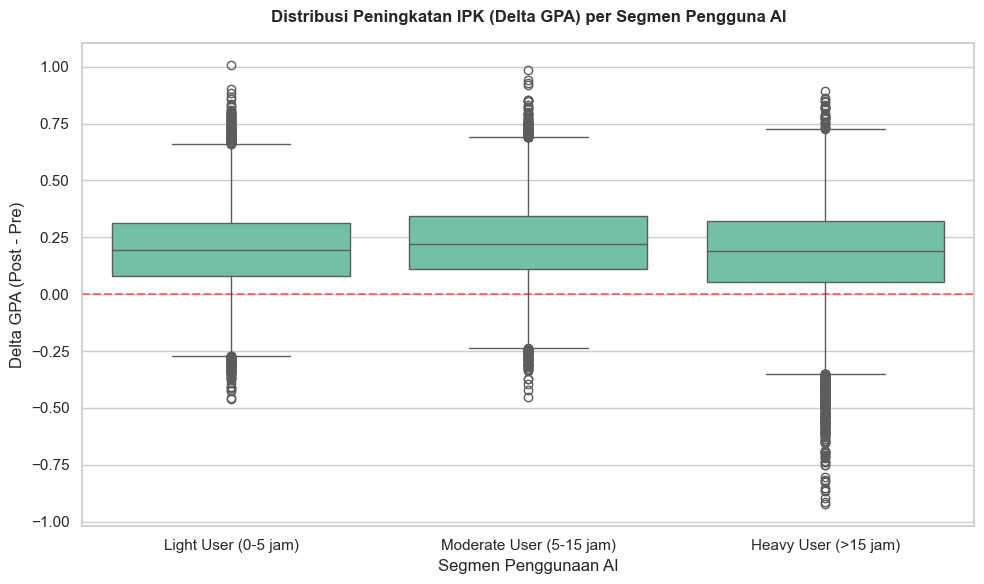

In [28]:
# 1. Investigasi bentuk asli data
print("Kategori asli di dalam dataset:")
print(df_clean['AI_Usage_Segment'].value_counts())
print("-" * 30)

# 2. Visualisasi versi paling aman (tanpa order dan palette)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='AI_Usage_Segment', 
    y='Delta_GPA',
    color='mediumaquamarine' # Menggunakan 1 warna solid agar tidak butuh 'hue'
)

plt.title('Distribusi Peningkatan IPK (Delta GPA) per Segmen Pengguna AI', pad=15, fontweight='bold')
plt.xlabel('Segmen Penggunaan AI')
plt.ylabel('Delta GPA (Post - Pre)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

In [29]:
# 1. Menyiapkan data tanpa hardcode nama kategori dan membuang nilai kosong (NaN)
df_uji = df_clean[['AI_Usage_Segment', 'Delta_GPA']].dropna()
groups = [group['Delta_GPA'].values for name, group in df_uji.groupby('AI_Usage_Segment')]

# 2. Uji One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"Hasil Uji ANOVA:")
print(f"F-Statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4e}\n")

# 3. Uji Lanjut (Post-Hoc Tukey HSD)
if p_value < 0.05:
    print("Kesimpulan: Terdapat perbedaan rata-rata Delta GPA yang signifikan (p < 0.05).")
    print("-" * 50)
    print("Hasil Uji Lanjut Tukey HSD:")
    tukey_result = pairwise_tukeyhsd(endog=df_uji['Delta_GPA'], groups=df_uji['AI_Usage_Segment'], alpha=0.05)
    print(tukey_result)
else:
    print("Kesimpulan: Tidak ada perbedaan yang signifikan antar segmen. Uji lanjut tidak diperlukan.")

Hasil Uji ANOVA:
F-Statistic : 290.5508
P-value     : 3.4927e-126

Kesimpulan: Terdapat perbedaan rata-rata Delta GPA yang signifikan (p < 0.05).
--------------------------------------------------
Hasil Uji Lanjut Tukey HSD:
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1                 group2          meandiff p-adj lower  upper  reject
---------------------------------------------------------------------------------
Heavy User (>15 jam)     Light User (0-5 jam)   0.0216   0.0 0.0161 0.0272   True
Heavy User (>15 jam) Moderate User (5-15 jam)    0.054   0.0 0.0483 0.0597   True
Light User (0-5 jam) Moderate User (5-15 jam)   0.0324   0.0 0.0281 0.0367   True
---------------------------------------------------------------------------------


**Observasi:** 
- Nilai tengah (median) peningkatan IPK tertinggi berada pada kelompok Moderate User. Sebaliknya, kelompok Heavy User justru memiliki rentang penurunan IPK yang paling ekstrem (terlihat dari outlier negatif yang menembus angka -1.00).

**Insight:**
- Terdapat batas optimal (sweet spot) dalam penggunaan AI. Penggunaan berlebihan (>15 jam/minggu) tidak berbanding lurus dengan nilai yang lebih tinggi, melainkan justru memicu risiko anjloknya prestasi, kemungkinan besar karena mahasiswa menjadi terlalu pasif atau sangat bergantung pada AI.

**Rekomendasi:**
- Kampus perlu menyosialisasikan panduan batas ideal pemakaian AI (berkisar 5-15 jam/minggu). Selain itu, jadikan intensitas penggunaan tinggi (Heavy User) sebagai salah satu metrik deteksi dini bagi dosen wali untuk memantau potensi penurunan akademik mahasiswa.


In [30]:
df_clean.to_csv('data/ai_student_clean.csv', index=False)

Secara keseluruhan, dataset mentah ini telah berhasil dieksplorasi, dibersihkan dari anomali logis, dan distrukturkan ulang. Dataset akhir (`ai_student_clean.csv`) kini telah terverifikasi dan siap 100% untuk diintegrasikan ke dalam *Business Intelligence Dashboard* guna memfasilitasi perumusan kebijakan kampus yang lebih tepat sasaran.